In [3]:
library(SoupX)
library(Seurat)
library(Matrix)
library(readxl)
library(writexl)


Running SoupX: cDNA-250114094

6668 genes passed tf-idf cut-off and 773 soup quantile filter.  Taking the top 100.

Using 1021 independent estimates of rho.

Estimated global rho of 0.06

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 21 clusters to 13986 cells.

Running SoupX: cDNA-250114095

6431 genes passed tf-idf cut-off and 762 soup quantile filter.  Taking the top 100.

Using 1080 independent estimates of rho.

Estimated global rho of 0.07



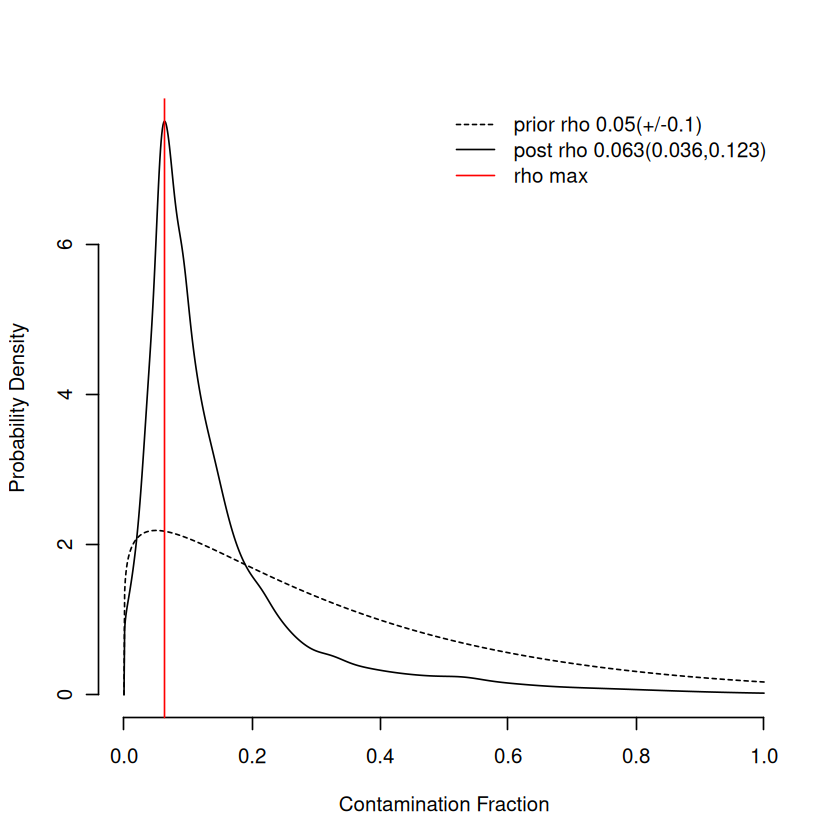

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 22 clusters to 14738 cells.

Running SoupX: cDNA-250114096

5509 genes passed tf-idf cut-off and 680 soup quantile filter.  Taking the top 100.

Using 777 independent estimates of rho.

Estimated global rho of 0.09



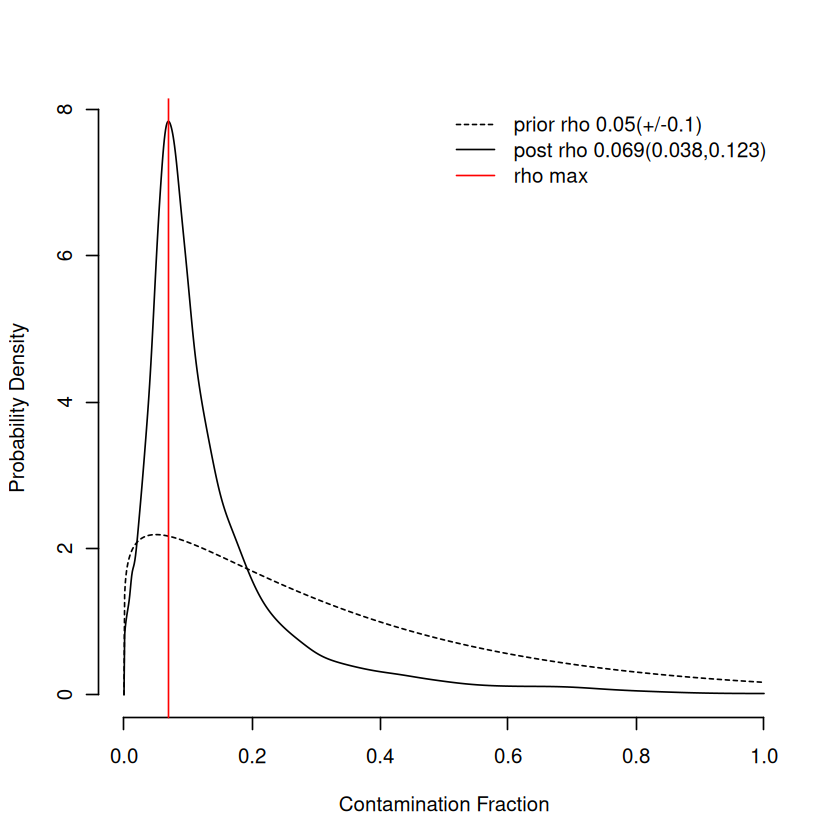

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 20 clusters to 14845 cells.

Running SoupX: cDNA-250114097

6605 genes passed tf-idf cut-off and 754 soup quantile filter.  Taking the top 100.

Using 879 independent estimates of rho.

Estimated global rho of 0.08



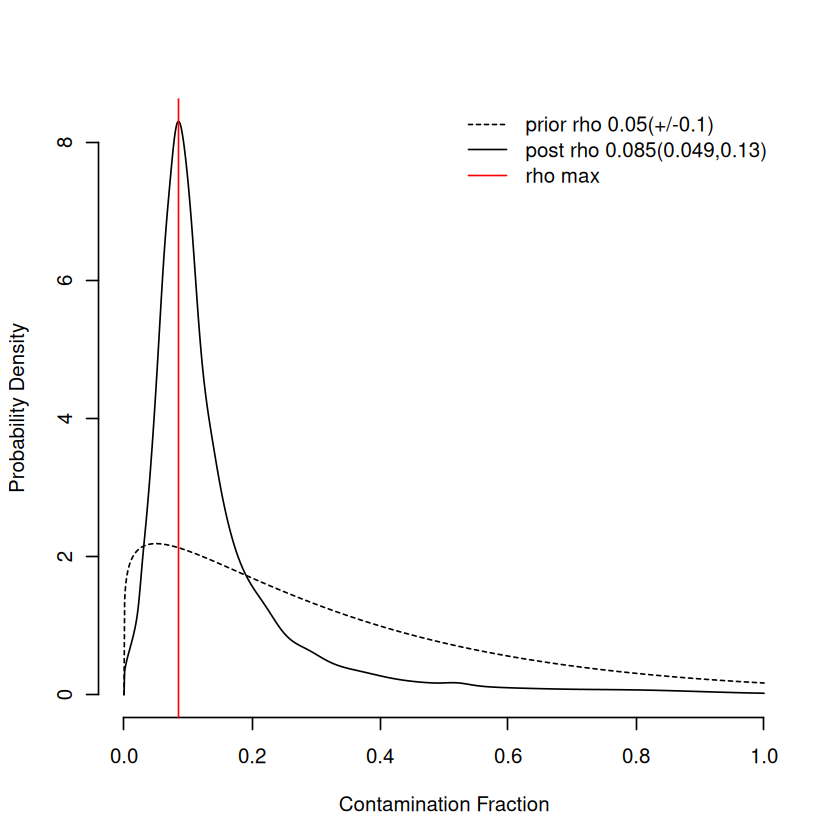

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 21 clusters to 14222 cells.

Running SoupX: cDNA-250114091

6195 genes passed tf-idf cut-off and 688 soup quantile filter.  Taking the top 100.

Using 647 independent estimates of rho.

Estimated global rho of 0.08



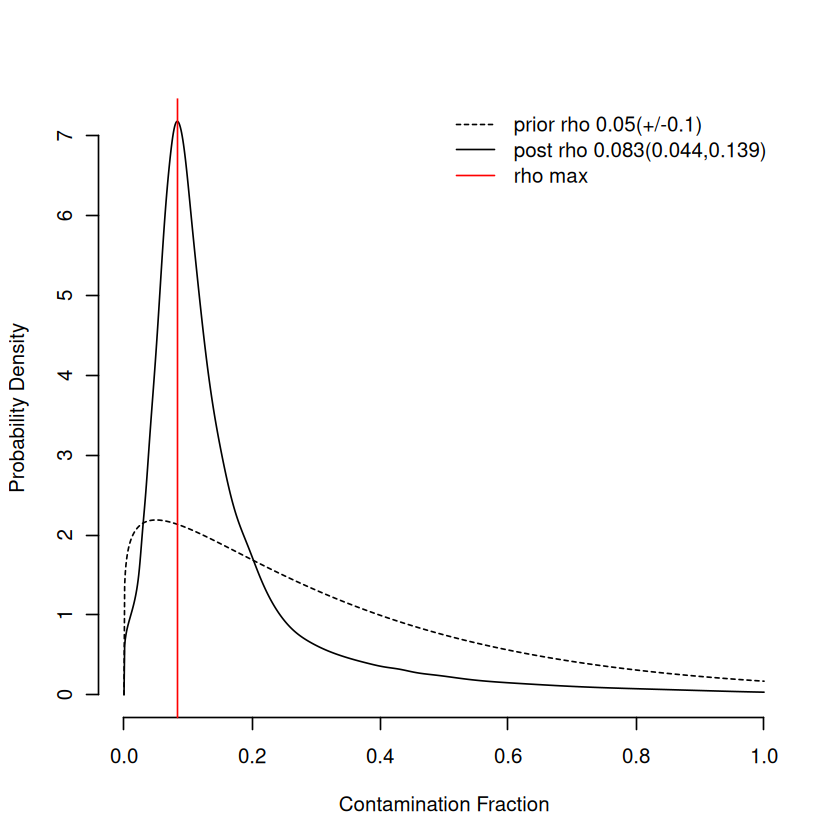

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 18 clusters to 14498 cells.

Running SoupX: cDNA-250114092

6238 genes passed tf-idf cut-off and 721 soup quantile filter.  Taking the top 100.

Using 581 independent estimates of rho.

Estimated global rho of 0.08



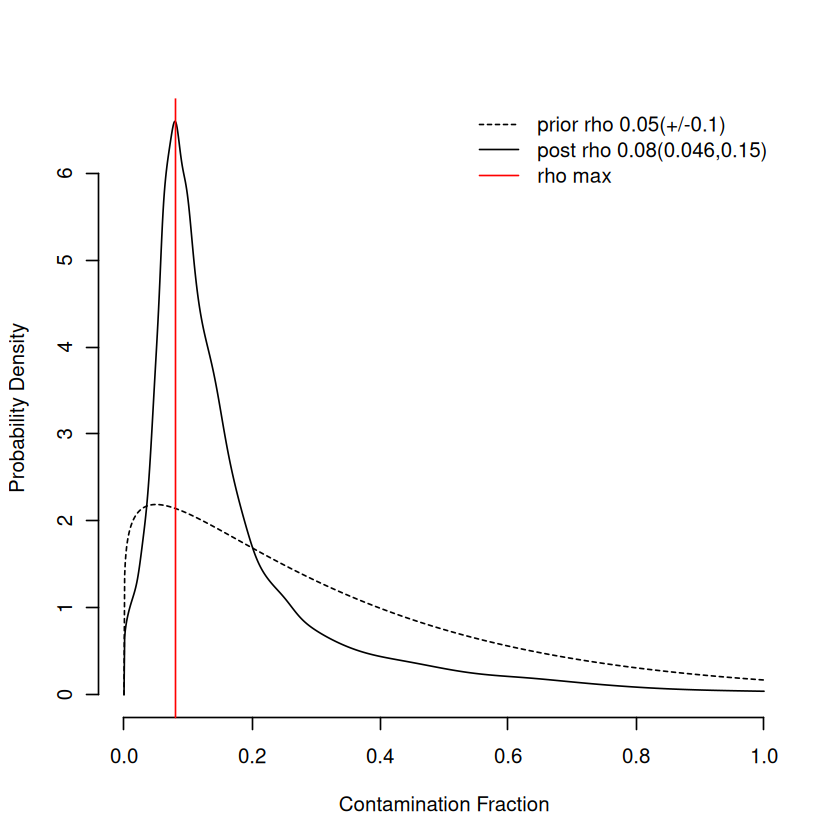

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 17 clusters to 14402 cells.

Running SoupX: cDNA-250114093

6696 genes passed tf-idf cut-off and 826 soup quantile filter.  Taking the top 100.

Using 833 independent estimates of rho.

Estimated global rho of 0.07



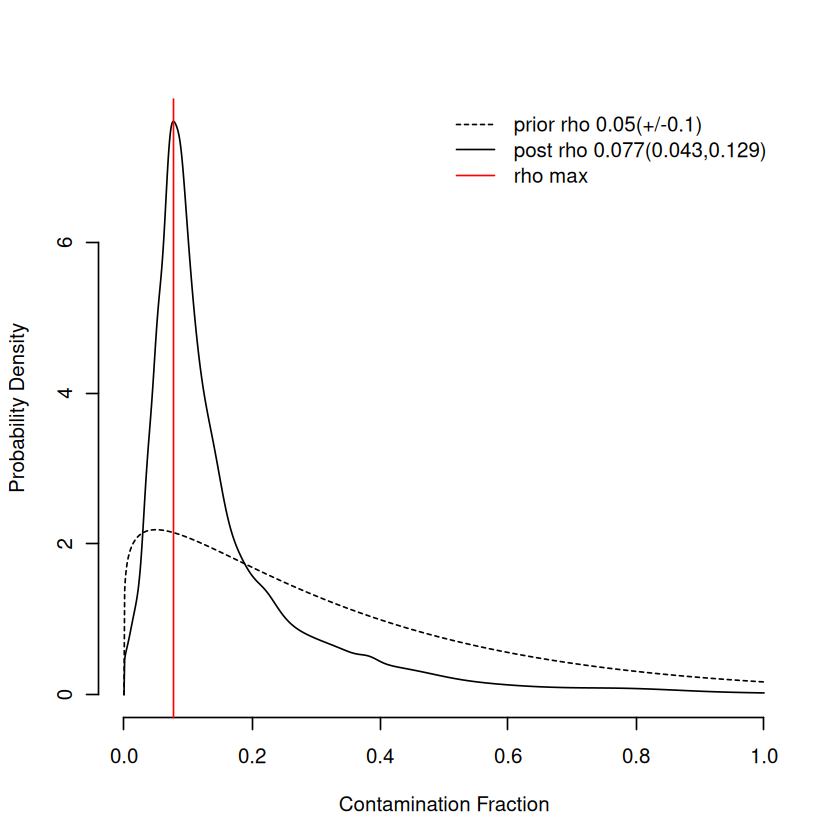

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 21 clusters to 14146 cells.



         Library area Animal sample_name n_raw_genes n_filter_cells
1 cDNA-250114094  VTA  Mq246  MQ246A-115       19375          13986
2 cDNA-250114095  VTA  Mq246  MQ246A-115       19411          14738
3 cDNA-250114096  VTA  Mq246  MQ246A-115       19431          14845
4 cDNA-250114097  VTA  Mq246  MQ246A-115       19470          14222
5 cDNA-250114091  VTA  Mq277  MQ277L-175       19614          14498
6 cDNA-250114092  VTA  Mq277  MQ277L-175       19553          14402
7 cDNA-250114093  VTA  Mq277  MQ277L-175       19458          14146
                                                                                 raw_matrix_path
1 /mnt/112-rawdata-112/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/raw_matrix
2 /mnt/112-rawdata-112/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114095/output/raw_matrix
3 /mnt/112-rawdata-112/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114096/output/raw_matrix
4 /mnt/112-rawdata-112/macaque/snRNA/resolved/20250430-zmy-anno/cDNA

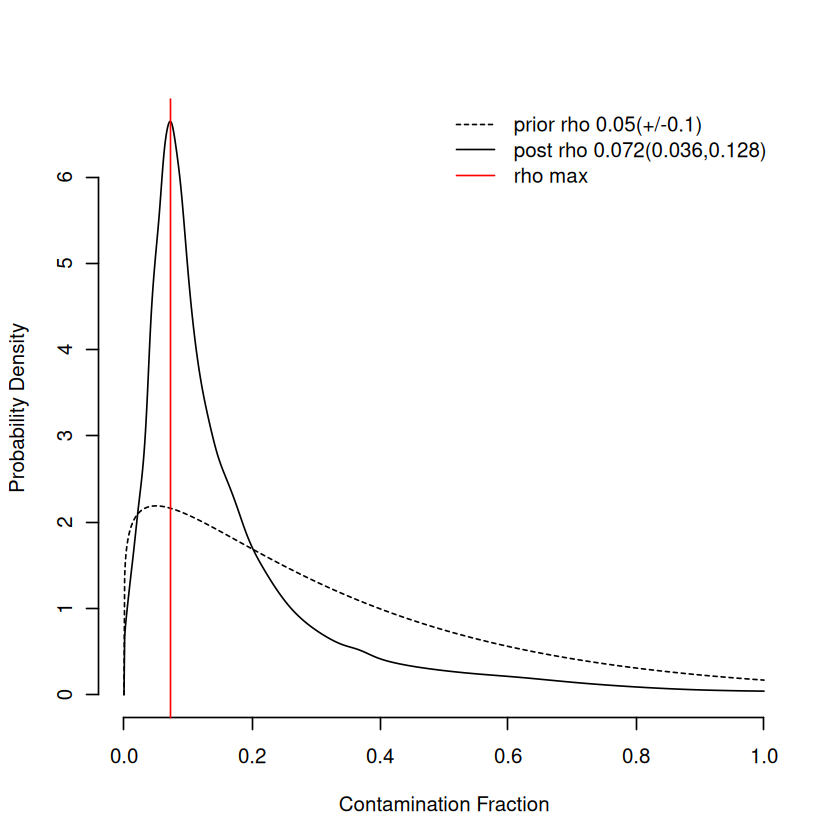

In [36]:

sample_info_path <- "/mnt/90-connectome/Personal/CQW/midbrain/mb_sample_info_resolved_paths.xlsx"
out_root <- "/mnt/90-connectome/Personal/CQW/midbrain/soupx_vta"
dir.create(out_root, recursive = TRUE, showWarnings = FALSE)

sample_info <- read_excel(sample_info_path)
vta_info <- sample_info[sample_info$area == "VTA", ]
summary_csv <- file.path(out_root, "soupx_vta_summary.csv")
summary_xlsx <- file.path(out_root, "soupx_vta_summary.xlsx")


run_one_library <- function(row) {
  library_id <- row[["Library"]]
  raw_dir <- row[["raw_matrix_path"]]
  filt_dir <- row[["filter_matrix_path"]]

  message("Running SoupX: ", library_id)

  tod <- Read10X(
    data.dir = raw_dir,
    gene.column = 1,
    unique.features = TRUE
  )
  toc <- Read10X(
    data.dir = filt_dir,
    gene.column = 1,
    unique.features = TRUE
  )

  common_genes <- intersect(rownames(tod), rownames(toc))
  tod <- tod[common_genes, ]
  toc <- toc[common_genes, ]

  seu <- CreateSeuratObject(toc, project = library_id, min.cells = 0, min.features = 0)
  seu <- NormalizeData(seu, verbose = FALSE)
  seu <- FindVariableFeatures(seu, nfeatures = 3000, verbose = FALSE)
  seu <- ScaleData(seu, verbose = FALSE)
  seu <- RunPCA(seu, npcs = 25, verbose = FALSE)
  seu <- FindNeighbors(seu, dims = 1:25, verbose = FALSE)
  seu <- FindClusters(seu, resolution = 0.5, verbose = FALSE)

  clusters <- setNames(seu$seurat_clusters, colnames(seu))
  stopifnot(all(colnames(toc) %in% names(clusters)))

  sc <- SoupChannel(tod = tod, toc = toc)
  sc <- setClusters(sc, clusters)
  sc <- autoEstCont(
    sc
  )

  corrected <- adjustCounts(sc, roundToInt = TRUE)

  lib_out <- file.path(out_root, library_id)
  dir.create(lib_out, recursive = TRUE, showWarnings = FALSE)

  writeMM(corrected, file.path(lib_out, "matrix.mtx"))
  writeLines(rownames(corrected), file.path(lib_out, "features.tsv"))
  writeLines(colnames(corrected), file.path(lib_out, "barcodes.tsv"))

  data.frame(
    Library = library_id,
    area = row[["area"]],
    Animal = row[["Animal"]],
    sample_name = row[["sample_name"]],
    n_raw_genes = nrow(tod),
    n_filter_cells = ncol(toc),
    raw_matrix_path = raw_dir,
    filter_matrix_path = filt_dir,
    output_dir = lib_out,
    soup_rho = sc$fit$rhoEst,
    stringsAsFactors = FALSE
  )
}


library(future.apply)

n_workers <- 4
plan(multisession, workers = n_workers)

summary_list <- future_lapply(
  seq_len(nrow(vta_info)),
  function(i) {
    run_one_library(vta_info[i, ])
  },
  future.seed = TRUE
)

summary_df <- do.call(rbind, summary_list)

write.csv(summary_df, summary_csv, row.names = FALSE)
write_xlsx(summary_df, summary_xlsx)

print(summary_df)
